In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Setup

In [1]:
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## 1. Get the Data

In [19]:
from sklearn.datasets import load_diabetes

diabetes_data = load_diabetes()
data = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
data['disease_progression'] = diabetes_data.target

print(diabetes_data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [20]:
data.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


### 1.1 Take quick look at Data Structure

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   bmi                  442 non-null    float64
 3   bp                   442 non-null    float64
 4   s1                   442 non-null    float64
 5   s2                   442 non-null    float64
 6   s3                   442 non-null    float64
 7   s4                   442 non-null    float64
 8   s5                   442 non-null    float64
 9   s6                   442 non-null    float64
 10  disease_progression  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [18]:
data['sex'].value_counts()

sex
-0.044642    235
 0.050680    207
Name: count, dtype: int64

Saving figure diabetes_attribute_histogram


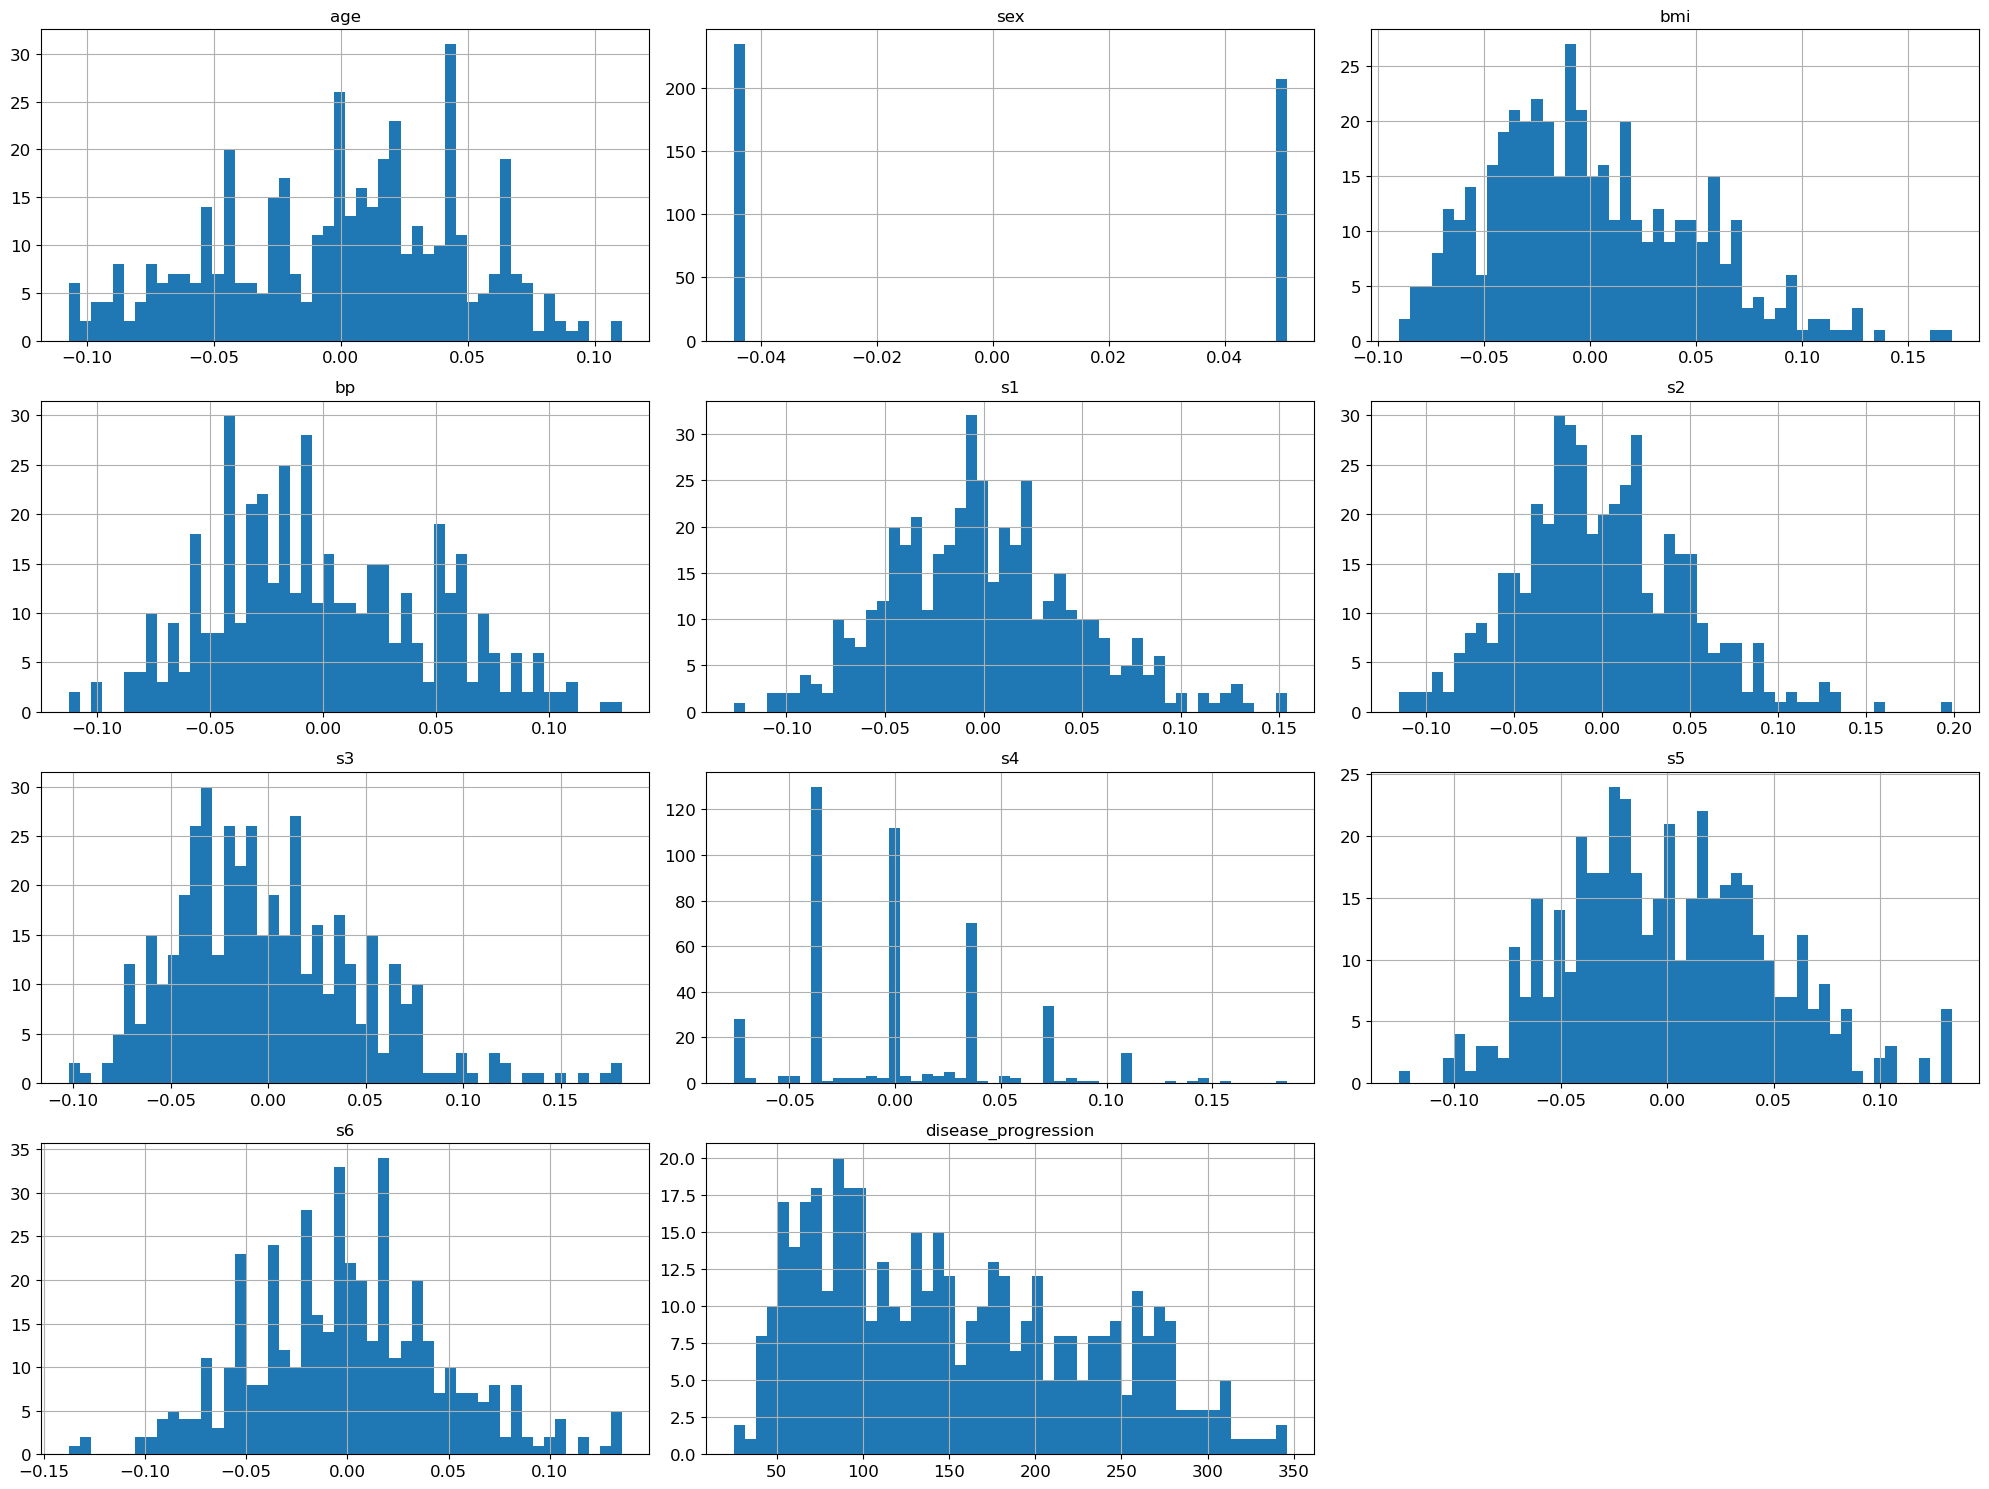

In [14]:
%matplotlib inline
data.hist(bins=50, figsize=(20, 15))
save_fig('diabetes_attribute_histogram')
plt.show()

### 1.2 Create Test Set

In [21]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)
print(train_set.shape)
print(test_set.shape)

(353, 11)
(89, 11)


## 2. Prepare Data for ML Algs

In [23]:
X_train, y_train = train_set.drop('disease_progression', axis=1), train_set['disease_progression']
X_test, y_test = test_set.drop('disease_progression', axis=1), test_set['disease_progression']
print(X_train.shape)
print(y_test.shape)

(353, 10)
(89,)


## 3. Select & Train a model

### 3.1 Training & evaluating on Train Set [baseline models]

In [44]:
# Ridge regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge_reg = Ridge(alpha=1e-7, solver='cholesky')
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_train)

ridge_mse = mean_squared_error(y_train, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
print(ridge_rmse)

53.55884336728476


In [47]:
# Lasso regression
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=1e-7)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_train)

lasso_mse = mean_squared_error(y_train, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
print(lasso_rmse)

53.55884336724849


In [51]:
# Elastic Net
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(max_iter=10000, alpha=1e-7, l1_ratio=0.1)
elastic_net.fit(X_train, y_train)
y_pred_net = elastic_net.predict(X_train)

elasticnet_mse = mean_squared_error(y_train, y_pred_net)
elasticnet_rmse = np.sqrt(elasticnet_mse)
print(elasticnet_rmse)

53.55884875478264


In [45]:
# SGDRegressor
from sklearn.linear_model import SGDRegressor

# using penalty='l2', which is like a sort of equivalence to Ridge regression
sgd_regressor = SGDRegressor(max_iter=10000, penalty='l2', alpha=1e-7)
sgd_regressor.fit(X_train, y_train)
y_pred_sgd = sgd_regressor.predict(X_train)

sgd_mse = mean_squared_error(y_train, y_pred_sgd)
sgd_rmse = np.sqrt(sgd_mse)
print(sgd_rmse)

54.13242494061781


In [56]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_forest = random_forest.predict(X_train)

forest_mse = mean_squared_error(y_train, y_pred_forest)
forest_rmse = np.sqrt(forest_mse)
print(forest_rmse)

21.459102805129884


In [60]:
# SVM
from sklearn.svm import LinearSVR

linear_svr = LinearSVR(C=1, epsilon=.5)
linear_svr.fit(X_train, y_train)
y_pred_linearsvr = linear_svr.predict(X_train)

linearsvr_mse = mean_squared_error(y_train, y_pred_linearsvr)
linearsvr_rmse = np.sqrt(linearsvr_mse)
print(linearsvr_rmse)

90.60804381839417


### 3.2 Better eval with Cross-Val 

In [62]:
# Lasso Regression
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

scores = cross_val_score(lasso_reg, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
lasso_rmse_scores = np.sqrt(-scores)
display_scores(lasso_rmse_scores)

Scores: [50.71007307 56.90915909 51.37657846 61.12863383 57.66165085 46.4273122
 51.39579732 60.45205035 59.60461536 60.6655698 ]
Mean: 55.63314403312539
Standard deviation: 4.952985355087175


In [63]:
# Random Forest
scores = cross_val_score(random_forest, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
forest_rmse_scores = np.sqrt(-scores)
display_scores(forest_rmse_scores)

Scores: [47.42659465 66.53046447 55.54107349 72.55723221 62.56225567 48.55494655
 60.58223794 62.30677131 53.52137853 56.55270078]
Mean: 58.61356556116294
Standard deviation: 7.45756391568049


In [64]:
# Ridge Regression
scores = cross_val_score(ridge_reg, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
ridge_rmse_scores = np.sqrt(-scores)
display_scores(ridge_rmse_scores)

Scores: [50.71006987 56.90916615 51.37657993 61.1286217  57.66164995 46.42731759
 51.39579575 60.45205328 59.60458237 60.66557121]
Mean: 55.63314078087451
Standard deviation: 4.952981260732641


## 4. Fine-Tune the Models

### 4.1 Grid Search

In [87]:
# Ridge Regression

from sklearn.model_selection import GridSearchCV

param_grid = [{
    'alpha': np.arange(0, 1, 1e-2),
    'max_iter': [5000, 10000, 100000],
    'solver': ['cholesky', 'svd', 'lsqr', 'sag']
}]

gridsearch_ridge = GridSearchCV(ridge_reg, param_grid, cv=5, 
                                scoring='neg_mean_squared_error', 
                                return_train_score=True)
gridsearch_ridge.fit(X_train, y_train)
print(gridsearch_ridge.best_params_)

,estimator,Ridge(alpha=1...er='cholesky')
,param_grid,"[{'alpha': array([0. , ... 0.99]), 'max_iter': [5000, 10000, ...], 'solver': ['cholesky', 'svd', ...]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,np.float64(0.07)


In [89]:
# Ridge Regression
ridge_best_model = gridsearch_ridge.best_estimator_

scores = cross_val_score(ridge_best_model, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
ridge_rmse_scores = np.sqrt(-scores)
display_scores(ridge_rmse_scores)

Scores: [50.31126185 57.90268308 51.75819952 60.2005717  57.96954704 46.63893882
 52.39388586 61.50555864 56.50272184 60.72418044]
Mean: 55.5907548785908
Standard deviation: 4.7680103812854036


In [84]:
# Random Forest

param_grid_forest = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
gridsearch_forest = GridSearchCV(random_forest, param_grid_forest, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
gridsearch_forest.fit(X_train, y_train)
print(gridsearch_forest.best_params_)

{'max_features': 4, 'n_estimators': 30}


In [86]:
# Random Forest
forest_best_model = gridsearch_forest.best_estimator_

scores = cross_val_score(forest_best_model, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
forest_rmse_scores = np.sqrt(-scores)
display_scores(forest_rmse_scores)

Scores: [48.75027129 65.87845594 58.38374779 70.70026762 60.69784207 47.62277466
 55.81153206 60.89306995 56.10441881 58.78842587]
Mean: 58.36308060541452
Standard deviation: 6.633947395657948


In [90]:
# Lasso Regression

param_grid_lasso = [{
    'alpha': np.arange(0, 1, 1e-2),
    'max_iter': [5000, 10000, 100000],
}]

gridsearch_lasso = GridSearchCV(lasso_reg, param_grid_lasso, cv=5, 
                                scoring='neg_mean_squared_error', 
                                return_train_score=True)
gridsearch_lasso.fit(X_train, y_train)
print(gridsearch_lasso.best_params_)

C:\anaconda3\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.118e+05, tolerance: 1.706e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\anaconda3\Lib\site-packages\sklea

{'alpha': np.float64(0.08), 'max_iter': 5000}


In [92]:
# Lasso Regression
lasso_best_model = gridsearch_lasso.best_estimator_

scores = cross_val_score(lasso_best_model, X_train, y_train, scoring='neg_mean_squared_error', cv=10)
lasso_rmse_scores = np.sqrt(-scores)
display_scores(lasso_rmse_scores)

Scores: [49.6572127  59.48019482 51.91171775 60.18952097 58.300319   46.72801177
 52.30603946 61.58058229 56.80866674 59.68198628]
Mean: 55.66442517714044
Standard deviation: 4.85533913579073


## 5. Evaluate on Test Set

In [94]:
# 1. Ridge
y_ridge_final_pred = ridge_best_model.predict(X_test)
final_ridge_mse = mean_squared_error(y_test, y_ridge_final_pred)
final_ridge_rmse = np.sqrt(final_ridge_mse)
print(final_ridge_rmse)

53.49236583961766


In [95]:
# 2. Lasso
y_lasso_final_pred = lasso_best_model.predict(X_test)
final_lasso_mse = mean_squared_error(y_test, y_lasso_final_pred)
final_lasso_rmse = np.sqrt(final_lasso_mse)
print(final_lasso_rmse)

52.91488545922437


In [96]:
# 3. Random Forest
y_forest_final_pred = forest_best_model.predict(X_test)
final_forest_mse = mean_squared_error(y_test, y_forest_final_pred)
final_forest_rmse = np.sqrt(final_forest_mse)
print(final_forest_mse)

3189.423158551811


## 6. Save the best model

In [98]:
import joblib
joblib.dump(lasso_best_model, 'my_models/diabetes_best_model.pkl')

['my_models/diabetes_best_model.pkl']